Cargando datos...


[*********************100%***********************]  23 of 23 completed


Datos cargados: 16200 días, 23 activos
Rango: 1962-01-03 → 2026-05-15
Ventana entrada=10, salida=5
  X_train: (14567, 10, 23) | y_train: (14567, 23)
  X_test:  (1619, 10, 23)  | y_test:  (1619, 23)

  Modelo: CNN_f32_k3_in10_out5_GAP
  Parámetros: 13,335


Model: "sequential_39"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_84 (Conv1D)              │ (None, 10, 32)         │         2,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_85 (Conv1D)              │ (None, 10, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_39     │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_100 (Dense)               │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_101 (Dense)               │ (None, 8)              │           520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_102 (Dense)               │ (None, 23)             │           207 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,335 (52.09 KB)

 Trainable params: 13,335 (52.09 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/500
410/410 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0121 - val_loss: 0.0106
Epoch 2/500
410/410 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0117 - val_loss: 0.0101
Epoch 3/500
410/410 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0112 - val_loss: 0.0096
Epoch 4/500
410/410 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0108 - val_loss: 0.0092
Epoch 5/500
410/410 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0104 - val_loss: 0.0088
Epoch 6/500
410/410 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0100 - val_loss: 0.0085
Epoch 7/500
410/410 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0096 - val_loss: 0.0081
Epoch 8/500
410/410 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0093 - val_loss: 0.0078
Epoch 9/500
410/410 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0090 - val_loss: 0.0075
Epoch 10/500
410/410 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0087 - val_loss: 0.0072
Epoch 11/500
410/410 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0084 - val_loss: 0.0069
Epoch 12/500
410/410 ━━━━━━━━━━━━━━━━━━━━

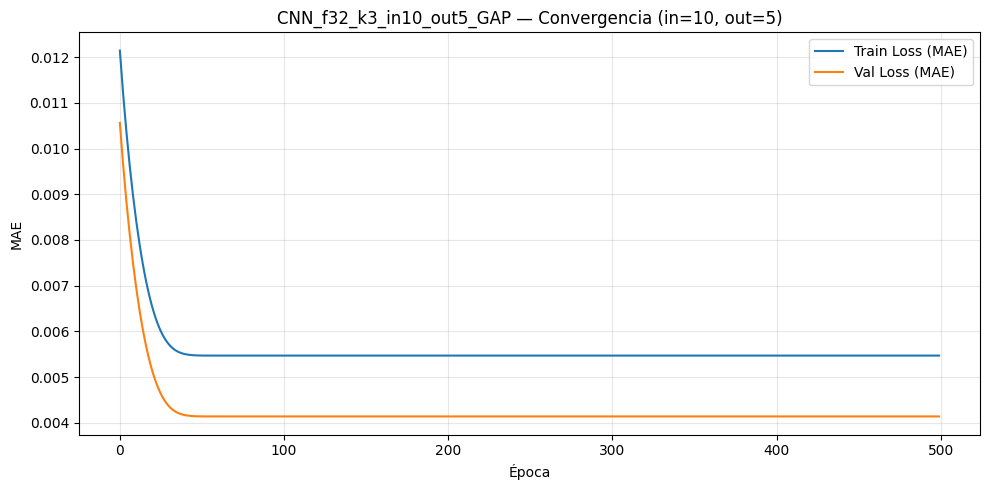

Modelo guardado en: models/CNN_f32_k3_in10_out5_GAP.keras


In [40]:
"""
cnn_model_single.py — Entrenamiento de CNN para UNA combinación de ventanas
=============================================================================

Cambia los parámetros en la sección CONFIGURACIÓN y ejecuta.
"""
import os
import sys
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Apuntar a la raíz del repositorio
os.chdir(r'C:\Users\eneko\neural-network-forecasting')
sys.path.insert(0, os.getcwd())

# Imports del repositorio
from config import RANDOM_SEED, MODELS_DIR, FIGURES_DIR
from src.data_pipeline import load_data, get_train_test
from src.evaluation import compute_mae, save_results, count_parameters
from src.plotting import plot_training_curves

np.random.seed(RANDOM_SEED)
import tensorflow as tf
tf.random.set_seed(RANDOM_SEED)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, GlobalAveragePooling1D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)
from tensorflow.keras.layers import SpatialDropout1D

# ============================================================================
# ▶▶▶ CONFIGURACIÓN — CAMBIA AQUÍ LOS PARÁMETROS ◀◀◀
# ============================================================================

INPUT_WINDOW = 10          # Ventana de entrada: 5, 10, 30 o 90
OUTPUT_WINDOW = 5        # Ventana de salida: 1, 5, 30 o 90
FILTERS = 32              # Filtros primera capa Conv1D
KERNEL_SIZE = 3           # Tamaño del kernel primera capa Conv1D
PADDING = 'same'          # 'same' o 'valid'
USE_MAXPOOL = False       # True → usa MaxPooling1D después de la primera Conv1D
POOL_SIZE = 2             # MaxPooling pool_size (solo si USE_MAXPOOL = True)
FILTERS_2 = 64            # Filtros segunda capa Conv1D (poner 0 para no usarla)
KERNEL_SIZE_2 = 3         # Tamaño del kernel segunda capa Conv1D
FILTERS_3 = 0             # Filtros tercera capa Conv1D (poner 0 para no usarla)
KERNEL_SIZE_3 = 3         # Tamaño del kernel tercera capa Conv1D
USE_GAP = True            # True → GlobalAveragePooling1D; False → Flatten
DENSE_1 = 64              # Neuronas primera capa densa
DENSE_2 = 8              # Neuronas segunda capa densa (poner 0 para no usarla)
DENSE_3 = 0               # Neuronas tercera capa densa (poner 0 para no usarla)
DROPOUT_RATE_1 = 0.0      # Dropout después de DENSE_1 (poner 0 para desactivar)
DROPOUT_RATE_2 = 0.0      # Dropout después de DENSE_2 (poner 0 para desactivar)
DROPOUT_RATE_3 = 0.0      # Dropout después de DENSE_3 (poner 0 para desactivar)
L2_REG = 0.0001           # Regularización L2 en capas Conv1D (poner 0 para desactivar)
SPATIAL_DROPOUT = 0.00    # poner 0 para desactivar
LEARNING_RATE = 0.00001
EPOCHS = 500
BATCH_SIZE = 32
PATIENCE = 120
VALIDATION_SPLIT = 0.1
MODEL_NAME = (f"CNN_f{FILTERS}_k{KERNEL_SIZE}_in{INPUT_WINDOW}_out{OUTPUT_WINDOW}"
              f"{'_MP' if USE_MAXPOOL else ''}"
              f"{'_GAP' if USE_GAP else ''}")


# ============================================================================
# CONSTRUCCIÓN DEL MODELO
# ============================================================================

def build_cnn(input_window, n_features=23):
    layers = [
        Conv1D(FILTERS, kernel_size=KERNEL_SIZE, activation='relu',
               input_shape=(input_window, n_features), padding=PADDING,
               kernel_regularizer=l2(L2_REG) if L2_REG > 0 else None),
    ]
    if SPATIAL_DROPOUT > 0:
        layers.append(SpatialDropout1D(SPATIAL_DROPOUT))

    if USE_MAXPOOL:
        layers.append(MaxPooling1D(pool_size=POOL_SIZE))

    if FILTERS_2 > 0:
        layers.append(Conv1D(FILTERS_2, kernel_size=KERNEL_SIZE_2, activation='relu',
                             padding='same',
                             kernel_regularizer=l2(L2_REG) if L2_REG > 0 else None))
        if SPATIAL_DROPOUT > 0:
            layers.append(SpatialDropout1D(SPATIAL_DROPOUT))

    if FILTERS_3 > 0:
        layers.append(Conv1D(FILTERS_3, kernel_size=KERNEL_SIZE_3, activation='relu',
                             padding='same',
                             kernel_regularizer=l2(L2_REG) if L2_REG > 0 else None))
        if SPATIAL_DROPOUT > 0:
            layers.append(SpatialDropout1D(SPATIAL_DROPOUT))

    layers.append(GlobalAveragePooling1D() if USE_GAP else Flatten())

    layers.append(Dense(DENSE_1, activation='relu'))
    if DROPOUT_RATE_1 > 0:
        layers.append(Dropout(DROPOUT_RATE_1))

    if DENSE_2 > 0:
        layers.append(Dense(DENSE_2, activation='relu'))
        if DROPOUT_RATE_2 > 0:
            layers.append(Dropout(DROPOUT_RATE_2))

    if DENSE_3 > 0:
        layers.append(Dense(DENSE_3, activation='relu'))
        if DROPOUT_RATE_3 > 0:
            layers.append(Dropout(DROPOUT_RATE_3))

    layers.append(Dense(n_features))

    model = Sequential(layers)
    model.compile(optimizer=Adam(learning_rate=LEARNING_RATE), loss='mae')
    return model


# ============================================================================
# ENTRENAMIENTO
# ============================================================================

print("Cargando datos...")
returns = load_data()

X_train, X_test, y_train, y_test = get_train_test(returns, INPUT_WINDOW, OUTPUT_WINDOW)

model = build_cnn(INPUT_WINDOW, n_features=X_train.shape[2])
n_params = count_parameters(model)

print(f"\n{'='*60}")
print(f"  Modelo: {MODEL_NAME}")
print(f"  Parámetros: {n_params:,}")
print(f"{'='*60}")
model.summary()

"""early_stop = EarlyStopping(
    monitor='val_loss',
    patience=PATIENCE,
    restore_best_weights=True,
    verbose=1
)"""

history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=VALIDATION_SPLIT,
    shuffle=True,
    #callbacks=[early_stop],
    verbose=1
)


# ============================================================================
# EVALUACIÓN
# ============================================================================

y_pred_train = model.predict(X_train, verbose=0)
y_pred_test = model.predict(X_test, verbose=0)

mae_train = compute_mae(y_train, y_pred_train)
mae_test = compute_mae(y_test, y_pred_test)
mae_val = min(history.history['val_loss']) if 'val_loss' in history.history else None

print(f"\n{'='*60}")
print(f"  Resultados {MODEL_NAME}:")
print(f"    MAE Train: {mae_train:.6f}")
if mae_val:
    print(f"    MAE Val:   {mae_val:.6f}")
print(f"    MAE Test:  {mae_test:.6f}")
print(f"{'='*60}")

save_results(
    model_name=MODEL_NAME,
    model_type='convolutional',
    input_window=INPUT_WINDOW,
    output_window=OUTPUT_WINDOW,
    mae_train=mae_train,
    mae_test=mae_test,
    n_params=n_params,
    mae_val=mae_val
)

plot_training_curves(history, MODEL_NAME, INPUT_WINDOW, OUTPUT_WINDOW, save=True)

model.save(os.path.join(MODELS_DIR, f"{MODEL_NAME}.keras"))
print(f"Modelo guardado en: {MODELS_DIR}{MODEL_NAME}.keras")